<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Data_Preprocessing_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [29]:
# Load CSV
file_path = '/content/drive/MyDrive/Customer_Churn_Data.csv'
data = pd.read_csv(file_path)

# Make a copy of the original dataset to work with
data_copy = data.copy()
df_dt = data_copy

# Quick check
df_dt.head()
df_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
# Convert TotalCharges to numeric
df_dt['TotalCharges_numeric'] = pd.to_numeric(df_dt['TotalCharges'], errors='coerce')

# Check how many missing values after conversion
print("Missing values in TotalCharges_numeric:", df_dt['TotalCharges_numeric'].isnull().sum())

# Impute missing values with median (robust for skewed data)
median_total = df_dt['TotalCharges_numeric'].median()
df_dt['TotalCharges_numeric'].fillna(median_total, inplace=True)

# Drop the original TotalCharges column
df_dt.drop(columns=['TotalCharges'], inplace=True)

Missing values in TotalCharges_numeric: 11


/tmp/ipython-input-372253789.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_dt['TotalCharges_numeric'].fillna(median_total, inplace=True)


In [31]:
# Drop customerID as it is not a predictive feature
df_dt.drop(columns=['customerID'], inplace=True)

In [32]:
# Feature Engineering
df_dt['AvgChargePerMonth'] = df_dt['TotalCharges_numeric'] / (df_dt['tenure'] + 1)

In [33]:
df_dt.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges_numeric,AvgChargePerMonth
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,29.85,14.925000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,No,1889.50,53.985714
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,108.15,36.050000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,1840.75,40.016304
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,151.65,50.550000


In [40]:
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

# Separate features and target
X = df_dt.drop('Churn', axis=1)
y = df_dt['Churn']

# Check numeric columns
numeric_cols = X.select_dtypes(include=np.number).columns

# Check for negative values
for col in numeric_cols:
    if (X[col] < 0).any():
        print(f"Column '{col}' has negative values")

# Check for NaNs or infinite values
print(X[numeric_cols].isnull().sum())
print(np.isinf(X[numeric_cols]).sum())

SeniorCitizen           0
tenure                  0
MonthlyCharges          0
TotalCharges_numeric    0
AvgChargePerMonth       0
dtype: int64
SeniorCitizen           0
tenure                  0
MonthlyCharges          0
TotalCharges_numeric    0
AvgChargePerMonth       0
dtype: int64


Categorical columns (excluding 'Churn'): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Top 12 Features with Chi-Squared Scores:
TotalCharges_numeric    627340.305176
tenure                   16278.923685
MonthlyCharges            3680.787699
Contract                  1115.780167
OnlineSecurity             551.611529
TechSupport                523.303866
OnlineBackup               230.086520
DeviceProtection           191.303140
SeniorCitizen              134.351545
Dependents                 133.036443
PaperlessBilling           105.680863
AvgChargePerMonth           94.812816
dtype: float64


/tmp/ipython-input-570834274.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features_log.values, y=top_features_log.index, palette='viridis')


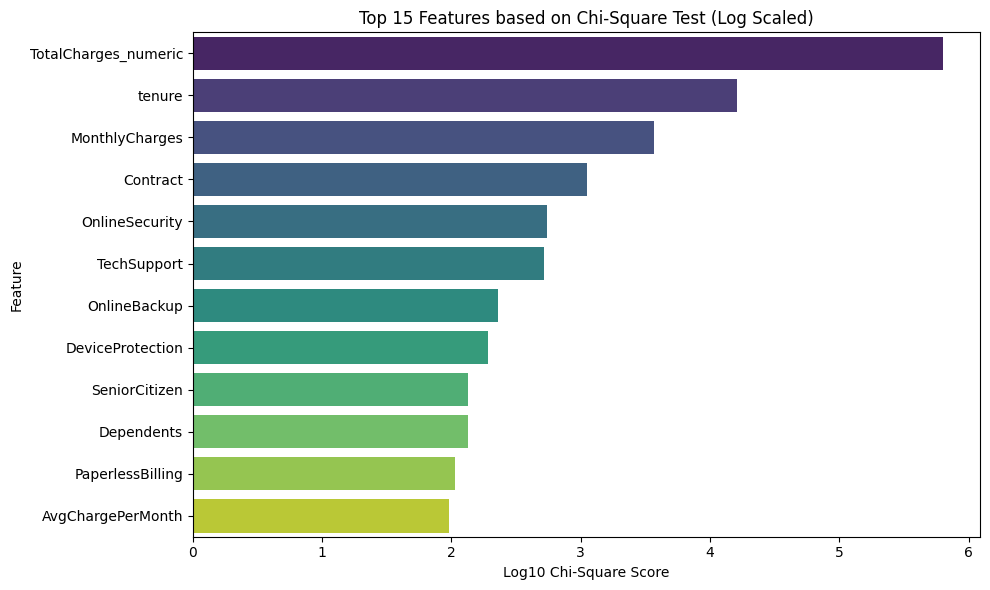

In [41]:
# Identify categorical columns (excluding target)
categorical_columns = df_dt.select_dtypes(include='object').columns.drop('Churn').tolist()
print("Categorical columns (excluding 'Churn'):", categorical_columns)

# Temporary Label Encoding for Chi-Square
df_label = df_dt.copy()
for col in categorical_columns:
    df_label[col] = LabelEncoder().fit_transform(df_label[col])

# Encode target for Chi-Square
y = df_label['Churn'].str.strip().map({'No': 0, 'Yes': 1})
X = df_label.drop('Churn', axis=1)

# Apply Chi-Square to select top k features
k = 12
selector = SelectKBest(score_func=chi2, k=k)
selector.fit(X, y)

chi_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
top_features = chi_scores.head(k)
print("Top 12 Features with Chi-Squared Scores:")
print(top_features)

# Plot log-scaled Chi-Square scores for visualization
top_features_log = np.log10(top_features + 1)  # add 1 to avoid log(0)
plt.figure(figsize=(10,6))
sns.barplot(x=top_features_log.values, y=top_features_log.index, palette='viridis')
plt.xlabel('Log10 Chi-Square Score')
plt.ylabel('Feature')
plt.title('Top 15 Features based on Chi-Square Test (Log Scaled)')
plt.tight_layout()
plt.show()

In [43]:
from sklearn.preprocessing import LabelEncoder

# Keep only top features in original df (not label encoded)
selected_features = top_features.index.tolist()
df_dt = df_dt[selected_features + ['Churn']]

# Apply Label Encoding ONLY on selected categorical columns
selected_cat_cols = [col for col in categorical_columns if col in selected_features]

le = LabelEncoder()
for col in selected_cat_cols:
    df_dt[col] = le.fit_transform(df_dt[col])

# Convert boolean columns to int
bool_cols = df_dt.select_dtypes(include='bool').columns
df_dt[bool_cols] = df_dt[bool_cols].astype(int)

# Encode target variable Churn
df_dt['Churn'] = df_dt['Churn'].str.strip().map({'No': 0, 'Yes': 1})

/tmp/ipython-input-4074652338.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dt[col] = le.fit_transform(df_dt[col])
/tmp/ipython-input-4074652338.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dt[col] = le.fit_transform(df_dt[col])
/tmp/ipython-input-4074652338.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [44]:
df_dt.head()

,TotalCharges_numeric,tenure,MonthlyCharges,Contract,OnlineSecurity,TechSupport,OnlineBackup,DeviceProtection,SeniorCitizen,Dependents,PaperlessBilling,AvgChargePerMonth,Churn
0,29.85,1,29.85,0,0,0,2,0,0,0,1,14.925000,0
1,1889.50,34,56.95,1,2,0,0,2,0,0,0,53.985714,0
2,108.15,2,53.85,0,2,0,2,0,0,0,1,36.050000,1
3,1840.75,45,42.30,1,2,2,0,2,0,0,0,40.016304,0
4,151.65,2,70.70,0,0,0,0,0,0,0,1,50.550000,1


In [45]:
df_dt.to_csv("/content/drive/MyDrive/processed_data_DT.csv", index=False)
print("Saved successfully!")

Saved successfully!
